<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/wrecking_ball.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Wrecking ball: $\theta_f$ as a function of $\theta_0$ for several values of k/W

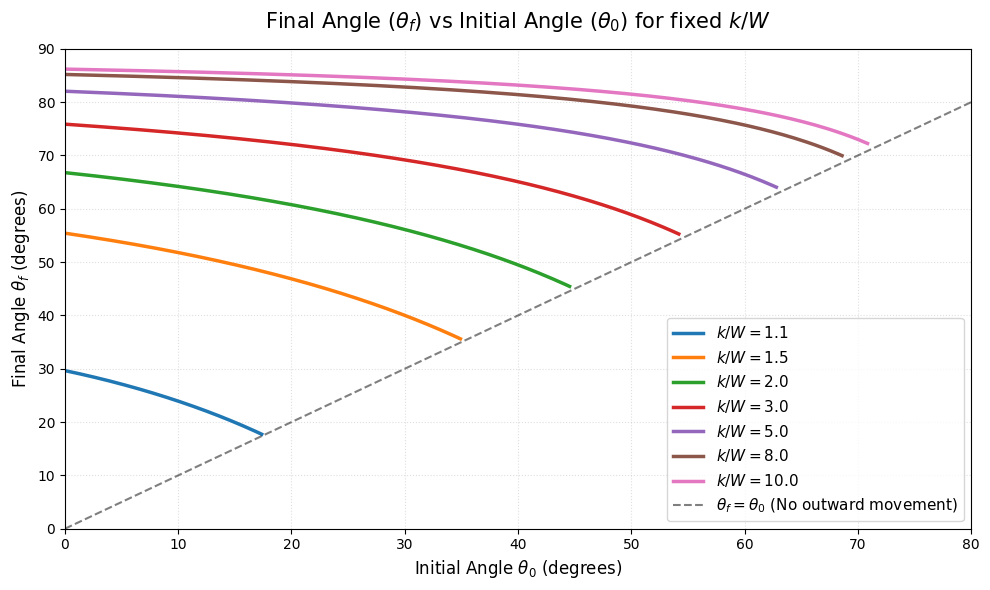

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Define our constant ratios kappa = k/W
# These represent the "stiffness" of the motorized pull relative to the weight
kappas = [1.1,1.5, 2.0, 3.0, 5.0, 8.0, 10.0]

plt.figure(figsize=(10, 6))

for kappa in kappas:
    # The minimum required stiffness is k/W > sec^2(theta_0)
    # Rearranging this tells us the MAXIMUM starting angle a given motor can pull from:
    # cos(theta_0) > 1 / sqrt(kappa) -> theta_0 < arccos(1 / sqrt(kappa))
    theta_0_max = np.arccos(1.0 / np.sqrt(kappa))

    # Create an array of theta_0 values from 0 up to 99% of the maximum allowed angle
    theta_0_rads = np.linspace(0, theta_0_max * 0.99, 200)
    theta_f_rads = []

    for th0 in theta_0_rads:
        # Define the implicit transcendental equation we want to solve for theta_f:
        # (tan(theta_f) - tan(theta_0)) / (theta_f - theta_0) - k/W = 0
        def objective(th_f):
            return (np.tan(th_f) - np.tan(th0)) / (th_f - th0) - kappa

        # We use root_scalar with a strict bracket to physically confine the solver.
        # It must search between the starting angle (th0) and the 90-degree asymptote (pi/2).
        # This prevents it from jumping the asymptote and finding non-physical infinite roots.
        try:
            sol = root_scalar(objective, bracket=[th0 + 1e-5, np.pi/2 - 1e-5])
            theta_f_rads.append(sol.root)
        except ValueError:
            # Fallback if the bracket fails (usually happens exactly at the mathematical limit)
            theta_f_rads.append(th0)

    # Plot the curve for this specific k/W ratio, converted to degrees for readability
    plt.plot(np.degrees(theta_0_rads), np.degrees(theta_f_rads),
             linewidth=2.5, label=f'$k/W = {kappa}$')

# Add a dashed reference line for theta_f = theta_0
# (The ball cannot stay beneath this line, or it means the motor pushed it backward!)
plt.plot([0, 90], [0, 90], 'k--', alpha=0.5, label=r'$\theta_f = \theta_0$ (No outward movement)')

# Formatting the plot
plt.title(r'Final Angle ($\theta_f$) vs Initial Angle ($\theta_0$) for fixed $k/W$', fontsize=15, pad=15)
plt.xlabel(r'Initial Angle $\theta_0$ (degrees)', fontsize=12)
plt.ylabel(r'Final Angle $\theta_f$ (degrees)', fontsize=12)
plt.xlim(0, 80)
plt.ylim(0, 90)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.4, linestyle=':')
plt.tight_layout()

# Display the plot
plt.show()